# Decaying Surface QG turbulence


A simulation of decaying surface quasi-geostrophic turbulence.
We reproduce here the initial value problem for an elliptical
vortex as done by Held et al. 1995, _J. Fluid Mech_.

In [1]:
using FourierFlows, Plots, Statistics, Printf, Random

using FFTW: irfft
using Statistics: mean
using Random: seed!

import GeophysicalFlows.SurfaceQG
import GeophysicalFlows.SurfaceQG: kinetic_energy, buoyancy_variance, buoyancy_dissipation

## Choosing a device: CPU or GPU

In [2]:
dev = CPU()    # Device (CPU/GPU)
nothing # hide

## Numerical parameters and time-stepping parameters

In [3]:
      n = 256                       # 2D resolution = n²
stepper = "FilteredETDRK4"          # timestepper
     dt = 0.03                      # timestep
     tf = 60                        # length of time for simulation
 nsteps = Int(tf / dt)              # total number of time-steps
 nsubs  = round(Int, nsteps/100)    # number of time-steps for intermediate logging/plotting (nsteps must be multiple of nsubs)
nothing # hide

## Physical parameters

In [4]:
  L = 2π        # domain size
 nν = 4
  ν = 1e-19
nothing # hide

## Problem setup
We initialize a `Problem` by providing a set of keyword arguments. In this
example numerical instability due to accumulation of buoyancy variance at high
wavenumbers is taken care with the `FilteredTimestepper` we picked.

In [5]:
prob = SurfaceQG.Problem(dev; nx=n, Lx=L, dt=dt, stepper=stepper, ν=ν, nν=nν)
nothing # hide

Let's define some shortcuts.

In [6]:
sol, clock, vars, params, grid = prob.sol, prob.clock, prob.vars, prob.params, prob.grid
x, y = grid.x, grid.y
nothing # hide

## Setting initial conditions

We initialize the buoyancy equation with an elliptical vortex.

In [7]:
X, Y = gridpoints(grid)
b₀ = @. exp(-(X^2 + 4*Y^2))

SurfaceQG.set_b!(prob, b₀)
nothing # hide

Let's plot the initial condition.

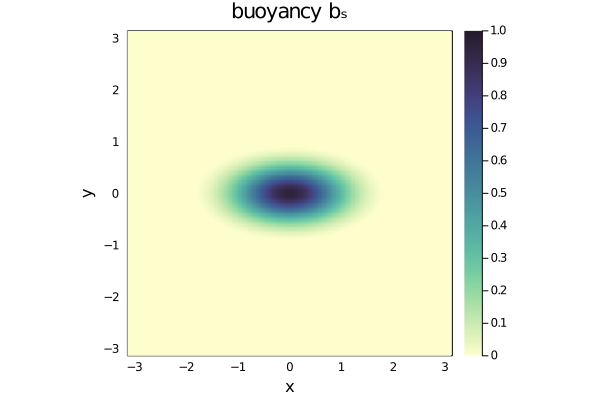

In [8]:
heatmap(x, y, prob.vars.b',
     aspectratio = 1,
               c = :deep,
            clim = (0, 1),
           xlims = (-grid.Lx/2, grid.Lx/2),
           ylims = (-grid.Ly/2, grid.Ly/2),
          xticks = -3:3,
          yticks = -3:3,
          xlabel = "x",
          ylabel = "y",
           title = "buoyancy bₛ",
      framestyle = :box)

## Diagnostics

Create Diagnostics; `buoyancy_variance`, `kinetic_energy` and `buoyancy_dissipation`
functions were imported at the top.

In [9]:
B  = Diagnostic(buoyancy_variance, prob; nsteps=nsteps)
KE = Diagnostic(kinetic_energy, prob; nsteps=nsteps)
Dᵇ = Diagnostic(buoyancy_dissipation, prob; nsteps=nsteps)
diags = [B, KE, Dᵇ] # A list of Diagnostics types passed to `stepforward!`. Diagnostics are updated every timestep.
nothing # hidenothing # hide

## Output

We choose folder for outputing `.jld2` files and snapshots (`.png` files).
Define base filename so saved data can be distinguished from other runs

In [10]:
base_filename = string("SurfaceQG_decaying_n_", n)

"SurfaceQG_decaying_n_256"

We choose folder for outputing `.jld2` files and snapshots (`.png` files).

In [11]:
datapath = "./"
plotpath = "./"

dataname = joinpath(datapath, base_filename)
plotname = joinpath(plotpath, base_filename)
nothing # hide

Do some basic file management,

In [12]:
if !isdir(plotpath); mkdir(plotpath); end
if !isdir(datapath); mkdir(datapath); end
nothing # hide

and then create Output.

In [13]:
get_sol(prob) = sol # extracts the Fourier-transformed solution
get_u(prob) = irfft(im * grid.l .* sqrt.(grid.invKrsq) .* sol, grid.nx)
out = Output(prob, dataname, (:sol, get_sol), (:u, get_u))
nothing # hide

## Visualizing the simulation

We define a function that plots the buoyancy field and the time evolution of
kinetic energy and buoyancy variance.

In [14]:
function plot_output(prob)
  bₛ = prob.vars.b
  uₛ = prob.vars.u
  vₛ = prob.vars.v

  pbₛ = heatmap(x, y, bₛ',
       aspectratio = 1,
                 c = :deep,
              clim = (0, 1),
             xlims = (-grid.Lx/2, grid.Lx/2),
             ylims = (-grid.Ly/2, grid.Ly/2),
            xticks = -3:3,
            yticks = -3:3,
            xlabel = "x",
            ylabel = "y",
             title = "buoyancy bₛ",
        framestyle = :box)

  pKE = plot(1,
             label = "kinetic energy ∫½(uₛ²+vₛ²)dxdy/L²",
         linewidth = 2,
            legend = :bottomright,
             alpha = 0.7,
             xlims = (0, tf),
             ylims = (0, 1e-2),
            xlabel = "t")

  pb² = plot(1,
             label = "buoyancy variance ∫bₛ²dxdy/L²",
         linecolor = :red,
            legend = :bottomright,
         linewidth = 2,
             alpha = 0.7,
             xlims = (0, tf),
             ylims = (0, 2e-2),
            xlabel = "t")

  layout = @layout [a{0.5w} Plots.grid(2, 1)]
  p = plot(pbₛ, pKE, pb², layout=layout, size = (900, 500), dpi=150)

  return p
end
nothing # hide

## Time-stepping the `Problem` forward and create animation by updating the plot.

In [15]:
startwalltime = time()

p = plot_output(prob)

anim = @animate for j=0:Int(nsteps/nsubs)

  cfl = clock.dt * maximum([maximum(vars.u) / grid.dx, maximum(vars.v) / grid.dy])

  if j%(500/nsubs)==0
    log1 = @sprintf("step: %04d, t: %.1f, cfl: %.3f, walltime: %.2f min",
          clock.step, clock.t, cfl, (time()-startwalltime)/60)
    log2 = @sprintf("buoyancy variance: %.2e, buoyancy variance dissipation: %.2e",
              B.data[B.i], Dᵇ.data[Dᵇ.i])
    println(log1)
    println(log2)
  end

  p[1][1][:z] = vars.b
  p[1][:title] = "buoyancy, t="*@sprintf("%.2f", clock.t)
  push!(p[2][1], KE.t[KE.i], KE.data[KE.i])
  push!(p[3][1], B.t[B.i], B.data[B.i])

  stepforward!(prob, diags, nsubs)
  SurfaceQG.updatevars!(prob)

end

mp4(anim, "sqg_ellipticalvortex.mp4", fps=14)

step: 0000, t: 0.0, cfl: 0.639, walltime: 0.01 min
buoyancy variance: 1.83e-02, buoyancy variance dissipation: 1.38e-16
step: 0500, t: 15.0, cfl: 0.588, walltime: 0.21 min
buoyancy variance: 1.83e-02, buoyancy variance dissipation: 3.93e-11
step: 1000, t: 30.0, cfl: 0.570, walltime: 0.39 min
buoyancy variance: 1.83e-02, buoyancy variance dissipation: 4.26e-09
step: 1500, t: 45.0, cfl: 0.568, walltime: 0.57 min
buoyancy variance: 1.82e-02, buoyancy variance dissipation: 8.53e-09
step: 2000, t: 60.0, cfl: 0.555, walltime: 0.75 min
buoyancy variance: 1.82e-02, buoyancy variance dissipation: 2.55e-09
┌ Info: Saved animation to 
│   fn = /home/runner/work/GeophysicalFlows.jl/GeophysicalFlows.jl/docs/src/generated/sqg_ellipticalvortex.mp4
└ @ Plots /home/runner/.julia/packages/Plots/SjqWU/src/animation.jl:104


Plots.AnimatedGif("/home/runner/work/GeophysicalFlows.jl/GeophysicalFlows.jl/docs/src/generated/sqg_ellipticalvortex.mp4")

Let's see how all flow fields look like at the end of the simulation.

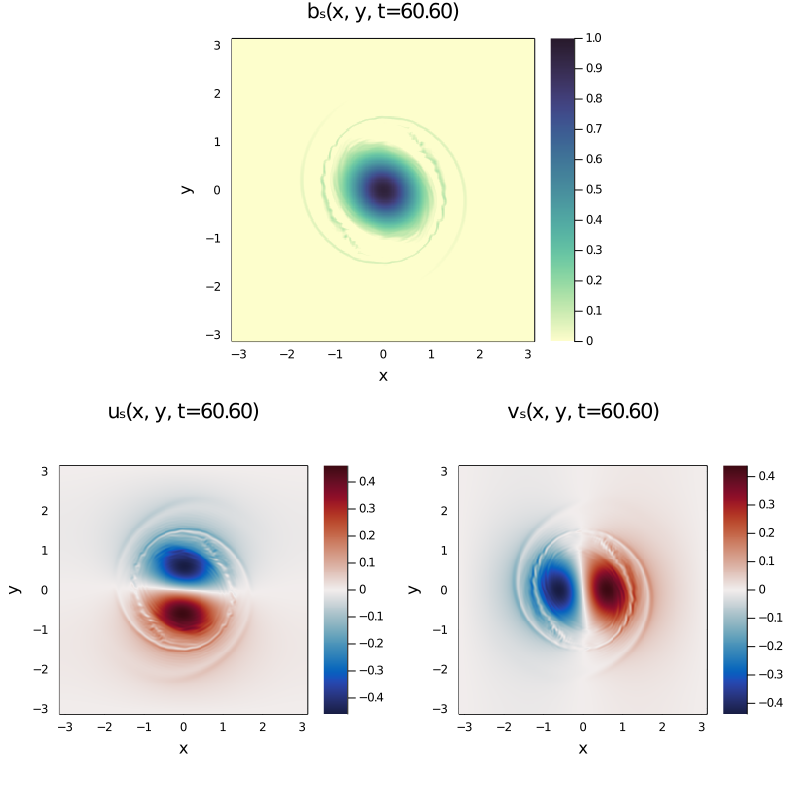

In [16]:
pu = heatmap(x, y, vars.u',
     aspectratio = 1,
               c = :balance,
            clim = (-maximum(abs.(vars.u)), maximum(abs.(vars.u))),
           xlims = (-L/2, L/2),
           ylims = (-L/2, L/2),
          xticks = -3:3,
          yticks = -3:3,
          xlabel = "x",
          ylabel = "y",
           title = "uₛ(x, y, t="*@sprintf("%.2f", clock.t)*")",
      framestyle = :box)

pv = heatmap(x, y, vars.v',
     aspectratio = 1,
               c = :balance,
            clim = (-maximum(abs.(vars.v)), maximum(abs.(vars.v))),
           xlims = (-L/2, L/2),
           ylims = (-L/2, L/2),
          xticks = -3:3,
          yticks = -3:3,
          xlabel = "x",
          ylabel = "y",
           title = "vₛ(x, y, t="*@sprintf("%.2f", clock.t)*")",
      framestyle = :box)

pb = heatmap(x, y, vars.b',
     aspectratio = 1,
               c = :deep,
            clim = (0, 1),
           xlims = (-L/2, L/2),
           ylims = (-L/2, L/2),
          xticks = -3:3,
          yticks = -3:3,
          xlabel = "x",
          ylabel = "y",
           title = "bₛ(x, y, t="*@sprintf("%.2f", clock.t)*")",
      framestyle = :box)

layout = @layout [a{0.5h}; b{0.5w} c{0.5w}]

plot_final = plot(pb, pu, pv, layout=layout, size = (800, 800))

Last we can save the output by calling `saveoutput(out)`.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*